In [3]:
import pandas as pd
df_train=pd.read_csv('data/train.csv')
df_test=pd.read_csv('data/test.csv')
df_train_merged = pd.read_csv('data/train_merged.csv')

In [4]:
def add_tire_life_columns(df):
    max_tire_life = {
        "MEDIUM": 40,
        "HARD": 55,
        "SOFT": 30,
        "INTERMEDIATE": 25,
        "WET": 20
    }

    df["MaxTireLife"] = df["Compound"].map(max_tire_life)

    df["TireRemainingLife"] = (
        df["MaxTireLife"] - df["TyreLife"]
    ).clip(lower=0)
    df["TireAgePct"] = (
    df["TyreLife"] / df["MaxTireLife"]).clip(0, 1)
    df["TireRemainingPct"] = (df["TireRemainingLife"] / df["MaxTireLife"]).clip(0, 1)
    

    return df

def add_laps_for_each_race(df):
    df["RaceLaps"] = (
    df["LapNumber"] / (df["RaceProgress"])
).round()
    df["LapsRemaining"] = df["RaceLaps"] - df["LapNumber"]
    return df


def prev_position_calcute(df):
    df["Prev_Position"] = df["Position"] + df["Position_Change"]
    return df


def get_trend_data(df):
    df["LapTimeAvg_3"] = (
        df.groupby(["Year", "Race", "Driver"])["LapTime (s)"]
        .transform(lambda x: x.rolling(3, min_periods=1).mean())
    )
    return df


def set_fe(df):
    df = add_tire_life_columns(df)
    df = add_laps_for_each_race(df)
    df= prev_position_calcute(df)
    df = get_trend_data(df)
    return df

In [5]:
df_train_merged = set_fe(df_train_merged)
df_train=set_fe(df_train)
df_test=set_fe(df_test)

In [6]:
from autogluon.tabular import TabularDataset, TabularPredictor
TARGET = 'PitNextLap'

print(df_train[TARGET].value_counts())
print(df_train_merged[TARGET].value_counts())

PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64
PitNextLap
0.0    427273
1.0    113172
Name: count, dtype: int64


In [7]:
import warnings
warnings.filterwarnings(
    "ignore", category=FutureWarning, message=".*downcast.*"
)
_orig_fillna = pd.DataFrame.fillna
def _patched_fillna(self, *args, **kwargs):
    kwargs.pop("downcast", None)
    return _orig_fillna(self, *args, **kwargs)

In [8]:
predictor = TabularPredictor.load(f"ag_models4")

In [38]:
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.960639,roc_auc,25.643816,1847.623462,0.049720,5.002925,2,True,5
1,CatBoost_BAG_L1,0.959373,roc_auc,3.641505,941.798194,3.641505,941.798194,1,True,3
2,XGBoost_BAG_L1,0.958686,roc_auc,3.976438,596.165577,3.976438,596.165577,1,True,4
3,LightGBMLarge_BAG_L1,0.953884,roc_auc,12.756626,198.343843,12.756626,198.343843,1,True,2
4,LightGBM_BAG_L1,0.951644,roc_auc,5.219527,106.312922,5.219527,106.312922,1,True,1


In [37]:
proba_df = predictor.predict_proba(df_train)
y_pred = proba_df.idxmax(axis=1)
y_true = df_train[TARGET]
accuracy = (y_true == y_pred).mean()
# Or: accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

# 4. Filter non-matching (misclassified) records
mismatched_mask = (y_true != y_pred)
mismatched_df = df_train[mismatched_mask].copy()

# 5. Append predicted class and confidence score for debugging
mismatched_df['actual'] = y_true[mismatched_mask]
mismatched_df['predicted'] = y_pred[mismatched_mask]
mismatched_df['confidence'] = proba_df.max(axis=1)[mismatched_mask]

# 1. Filter matching (correctly classified) records
matched_mask = (y_true == y_pred)
matched_df = df_train[matched_mask].copy()

# 2. Append actual target, predicted class, and confidence score for analysis
matched_df['actual'] = y_true[matched_mask]
matched_df['predicted'] = y_pred[matched_mask]
matched_df['confidence'] = proba_df.max(axis=1)[matched_mask]

output_df = df_train.copy()
output_df['actual'] = y_true[matched_mask]
output_df['predicted'] = y_pred[matched_mask]
output_df['confidence'] = proba_df.max(axis=1)[matched_mask]

# View matched records
# print(f"Total correctly classified records: {len(matched_df)}")
# matched_df.head()


# View misclassified records
print(f"Total misclassified records: {len(mismatched_df)}")
mismatched_df.head()

Accuracy: 92.84%
Total misclassified records: 31453


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,...,TireRemainingLife,TireAgePct,TireRemainingPct,RaceLaps,LapsRemaining,Prev_Position,LapTimeAvg_3,actual,predicted,confidence
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,...,48.0,0.127273,0.872727,78.0,51.0,1.0,75.095,0.0,1,0.535197
40,40,D117,HARD,Italian Grand Prix,2024,0,30,3,15.0,17,...,40.0,0.272727,0.727273,71.0,41.0,17.0,89.958,0.0,1,0.781443
51,51,WIL,HARD,Italian Grand Prix,2022,1,24,2,21.0,14,...,34.0,0.381818,0.618182,72.0,48.0,19.0,87.865,0.0,1,0.517387
52,52,CAR,HARD,Chinese Grand Prix,2024,0,31,3,9.0,16,...,46.0,0.163636,0.836364,71.0,40.0,17.0,101.849,0.0,1,0.800930
60,60,D293,HARD,Dutch Grand Prix,2025,0,41,2,20.0,9,...,35.0,0.363636,0.636364,76.0,35.0,11.0,75.942,0.0,1,0.769621


In [10]:
print(f"Total correctly classified records: {len(matched_df)}")

Total correctly classified records: 407687


In [11]:
mismatched_df[mismatched_df["predicted"]==1]

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,...,TireRemainingLife,TireAgePct,TireRemainingPct,RaceLaps,LapsRemaining,Prev_Position,LapTimeAvg_3,actual,predicted,confidence
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,...,48.0,0.127273,0.872727,78.0,51.0,1.0,75.095000,0.0,1,0.535197
40,40,D117,HARD,Italian Grand Prix,2024,0,30,3,15.0,17,...,40.0,0.272727,0.727273,71.0,41.0,17.0,89.958000,0.0,1,0.781443
51,51,WIL,HARD,Italian Grand Prix,2022,1,24,2,21.0,14,...,34.0,0.381818,0.618182,72.0,48.0,19.0,87.865000,0.0,1,0.517387
52,52,CAR,HARD,Chinese Grand Prix,2024,0,31,3,9.0,16,...,46.0,0.163636,0.836364,71.0,40.0,17.0,101.849000,0.0,1,0.800930
60,60,D293,HARD,Dutch Grand Prix,2025,0,41,2,20.0,9,...,35.0,0.363636,0.636364,76.0,35.0,11.0,75.942000,0.0,1,0.769621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438978,438978,D184,HARD,Austrian Grand Prix,2024,0,47,3,18.0,14,...,37.0,0.327273,0.672727,77.0,30.0,7.0,71.729667,0.0,1,0.725281
439002,439002,HEI,HARD,Saudi Arabian Grand Prix,2025,0,34,2,20.0,13,...,35.0,0.363636,0.636364,72.0,38.0,10.0,94.038667,0.0,1,0.788185
439060,439060,D141,MEDIUM,Monaco Grand Prix,2025,0,66,3,32.0,15,...,8.0,0.800000,0.200000,76.0,10.0,15.0,84.826000,0.0,1,0.616821
439093,439093,D019,HARD,Monaco Grand Prix,2024,0,25,2,25.0,1,...,30.0,0.454545,0.545455,78.0,53.0,8.0,80.373000,0.0,1,0.900390


In [12]:
mismatched_df[mismatched_df["predicted"]==0].count()

id                        16885
Driver                    16885
Compound                  16885
Race                      16885
Year                      16885
PitStop                   16885
LapNumber                 16885
Stint                     16885
TyreLife                  16885
Position                  16885
LapTime (s)               16885
LapTime_Delta             16885
Cumulative_Degradation    16885
RaceProgress              16885
Position_Change           16885
PitNextLap                16885
MaxTireLife               16885
TireRemainingLife         16885
TireAgePct                16885
TireRemainingPct          16885
RaceLaps                  16885
LapsRemaining             16885
Prev_Position             16885
LapTimeAvg_3              16885
actual                    16885
predicted                 16885
confidence                16885
dtype: int64

In [13]:
import matplotlib.pyplot as plt
def get_graph(df):

    columns = [
        'Compound',  'MaxTireLife', 'TireRemainingLife', 'TireAgePct','TireRemainingPct', 'TyreLife',
        'LapNumber' , 'RaceLaps', 'LapsRemaining',
        'LapTimeAvg_3', 'LapTime (s)', 'LapTime_Delta',
        'Stint',
        'Cumulative_Degradation', 'RaceProgress',
        'Prev_Position', 'Position', 'Position_Change',
        'Race', 'Year', 'PitStop','PitNextLap'
    ]

    # Don't plot the target itself
    columns_to_plot = [c for c in columns if c != 'PitNextLap']

    df_plot = df.copy()

    for col in columns_to_plot:

        fig, axes = plt.subplots(
            1, 2,
            figsize=(14, 5),
            sharey=False
        )

        data_0 = df_plot.loc[df_plot['PitNextLap'] == 0, col].dropna()
        data_1 = df_plot.loc[df_plot['PitNextLap'] == 1, col].dropna()

        # -------------------------
        # Numeric columns
        # -------------------------
        if pd.api.types.is_numeric_dtype(df_plot[col]):

            axes[0].hist(
                data_0,
                bins=30,
                alpha=0.75
            )
            axes[0].set_title(f'{col} | PitNextLap = 0')
            axes[0].set_xlabel(col)
            axes[0].set_ylabel('Count')
            axes[0].grid(alpha=0.2)

            axes[1].hist(
                data_1,
                bins=30,
                alpha=0.75
            )
            axes[1].set_title(f'{col} | PitNextLap = 1')
            axes[1].set_xlabel(col)
            axes[1].set_ylabel('Count')
            axes[1].grid(alpha=0.2)

        # -------------------------
        # Categorical columns
        # -------------------------
        else:

            counts_0 = data_0.value_counts().head(20)
            counts_1 = data_1.value_counts().head(20)

            axes[0].bar(
                counts_0.index.astype(str),
                counts_0.values
            )
            axes[0].set_title(f'{col} | PitNextLap = 0')
            axes[0].set_xlabel(col)
            axes[0].set_ylabel('Count')
            axes[0].tick_params(axis='x', rotation=75)
            axes[0].grid(axis='y', alpha=0.2)

            axes[1].bar(
                counts_1.index.astype(str),
                counts_1.values
            )
            axes[1].set_title(f'{col} | PitNextLap = 1')
            axes[1].set_xlabel(col)
            axes[1].set_ylabel('Count')
            axes[1].tick_params(axis='x', rotation=75)
            axes[1].grid(axis='y', alpha=0.2)

        plt.suptitle(
            f'Distribution of {col} by PitNextLap',
            fontsize=14,
            fontweight='bold'
        )

        plt.tight_layout()
        plt.show()

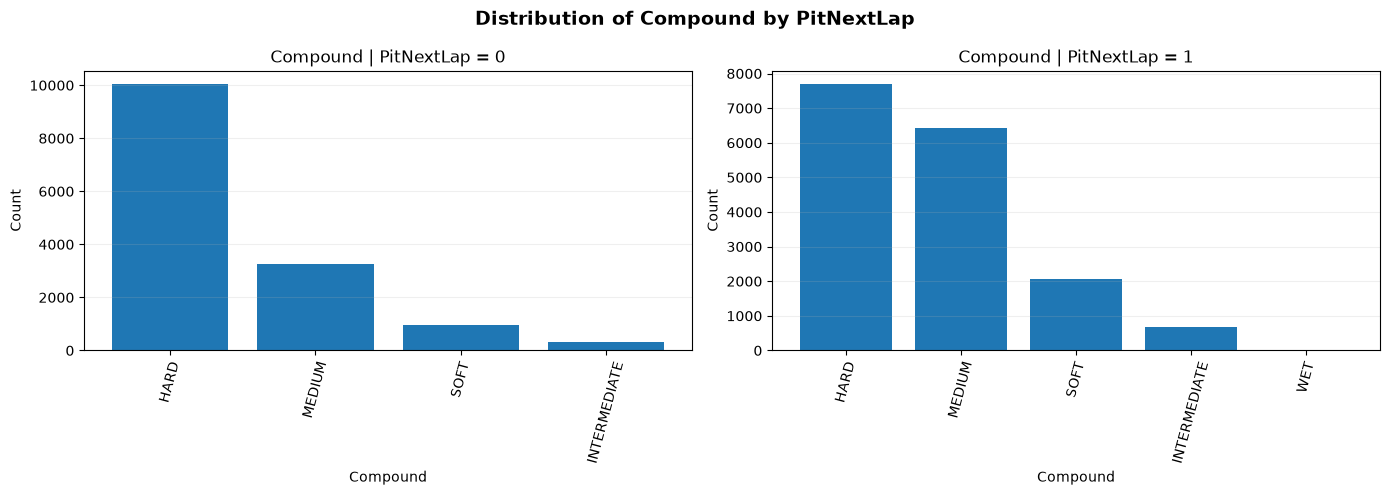

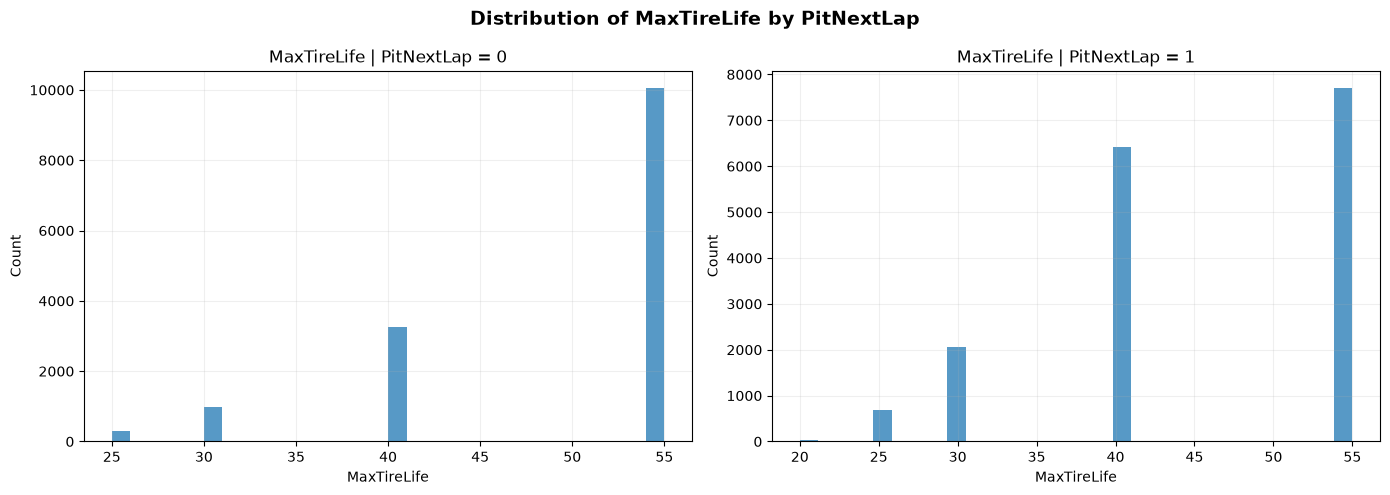

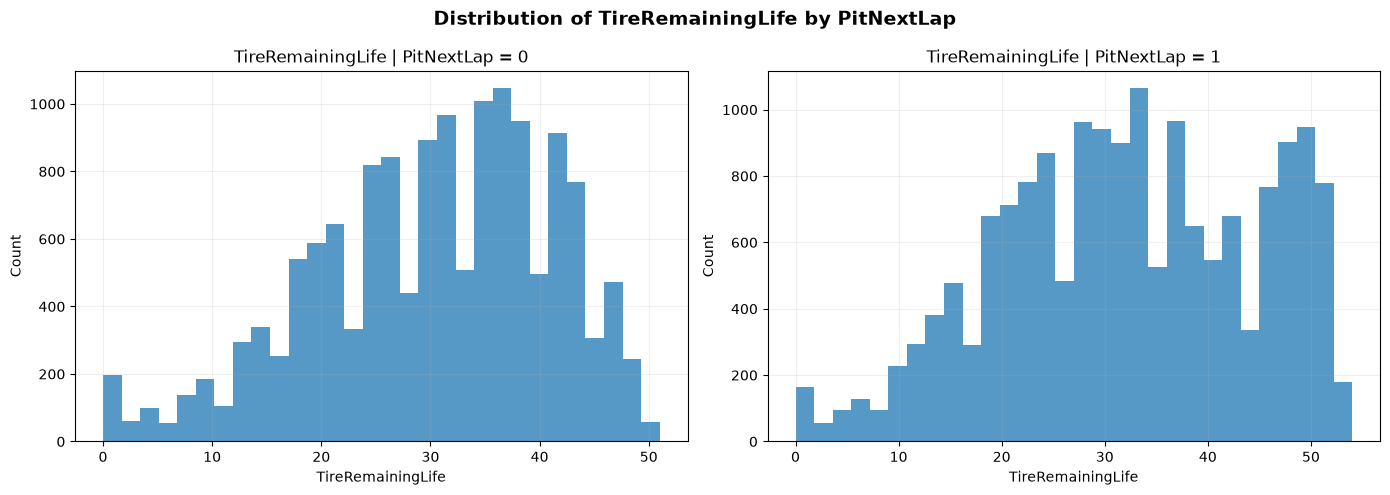

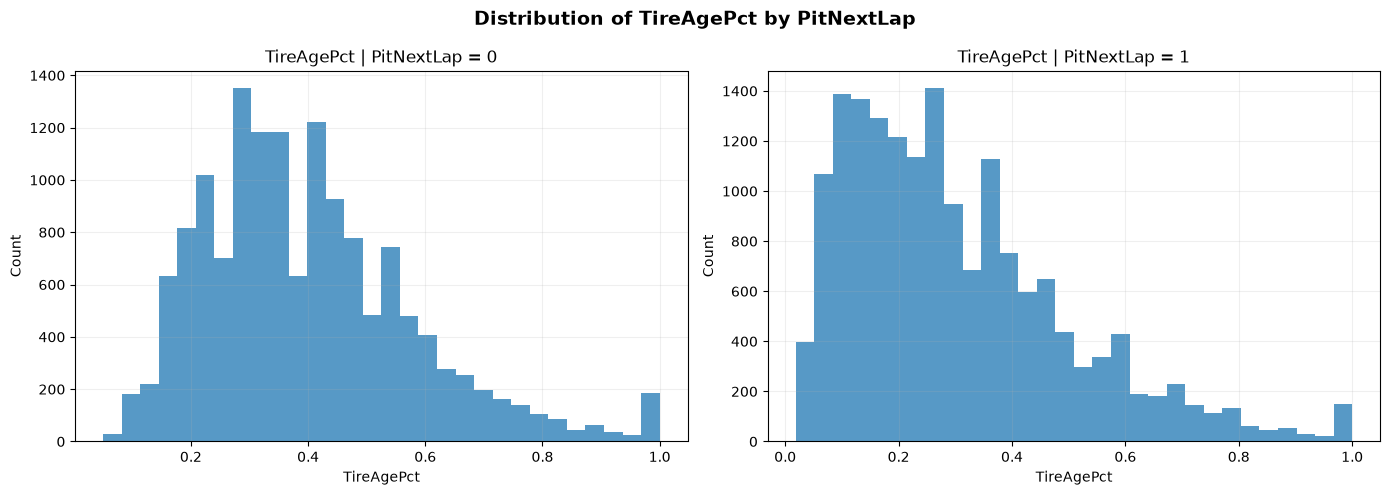

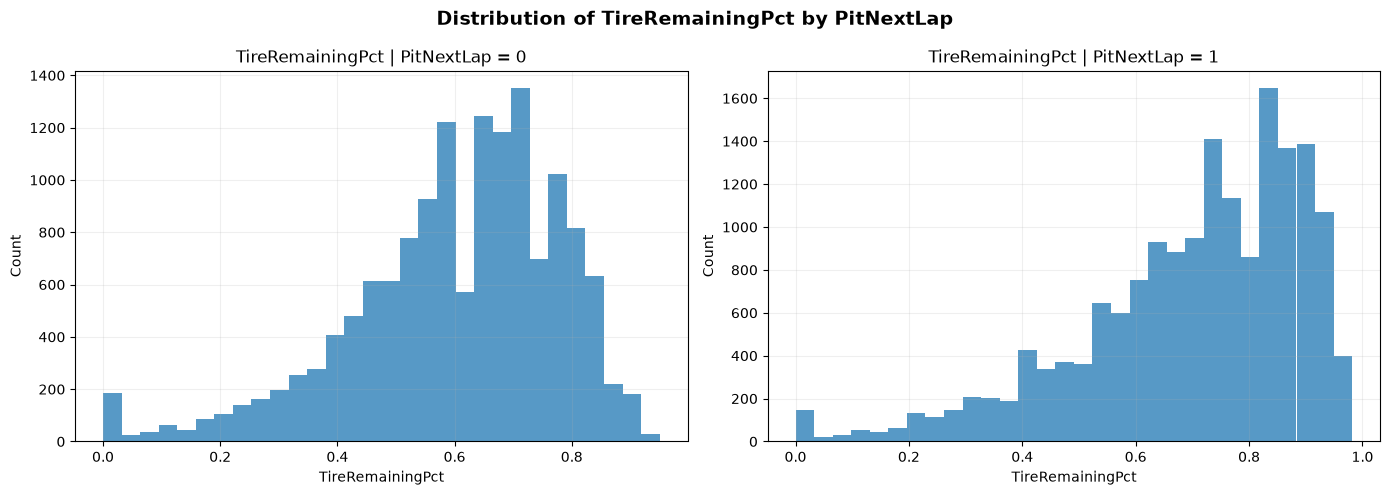

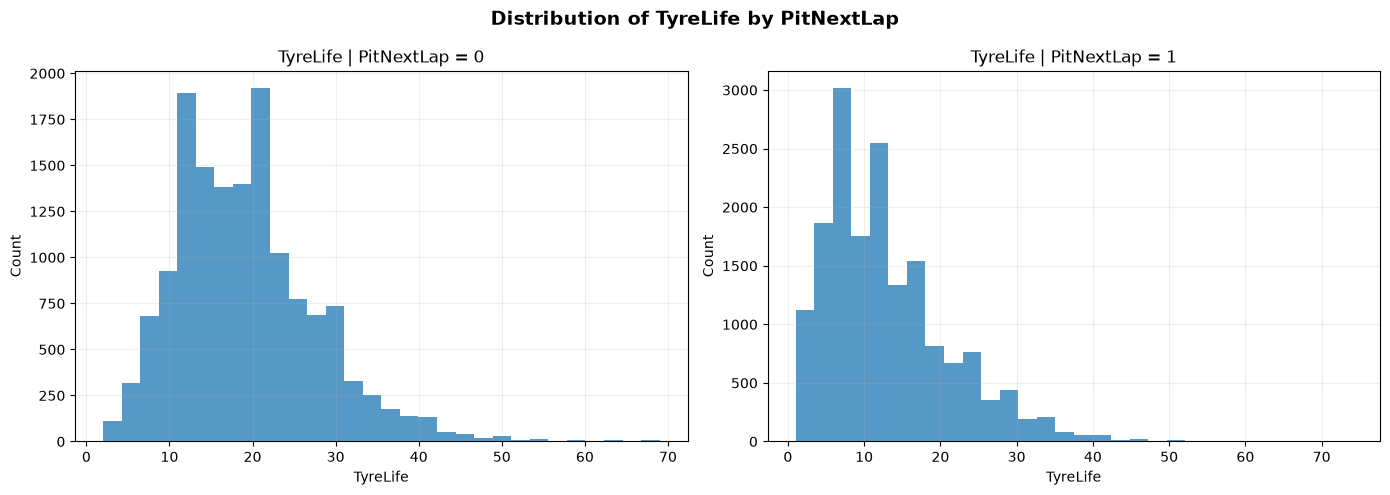

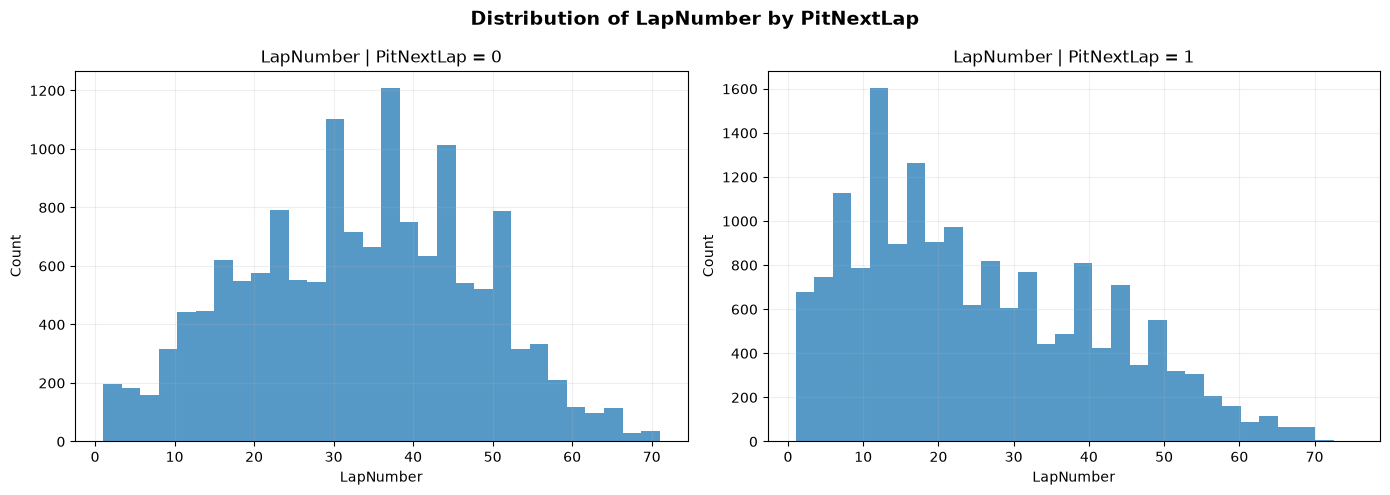

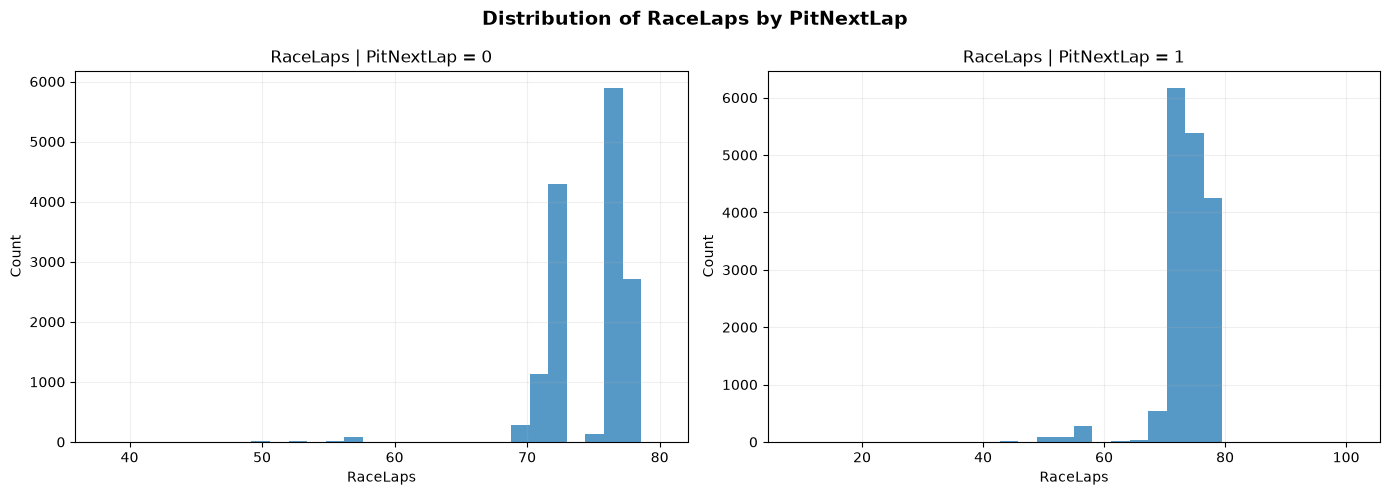

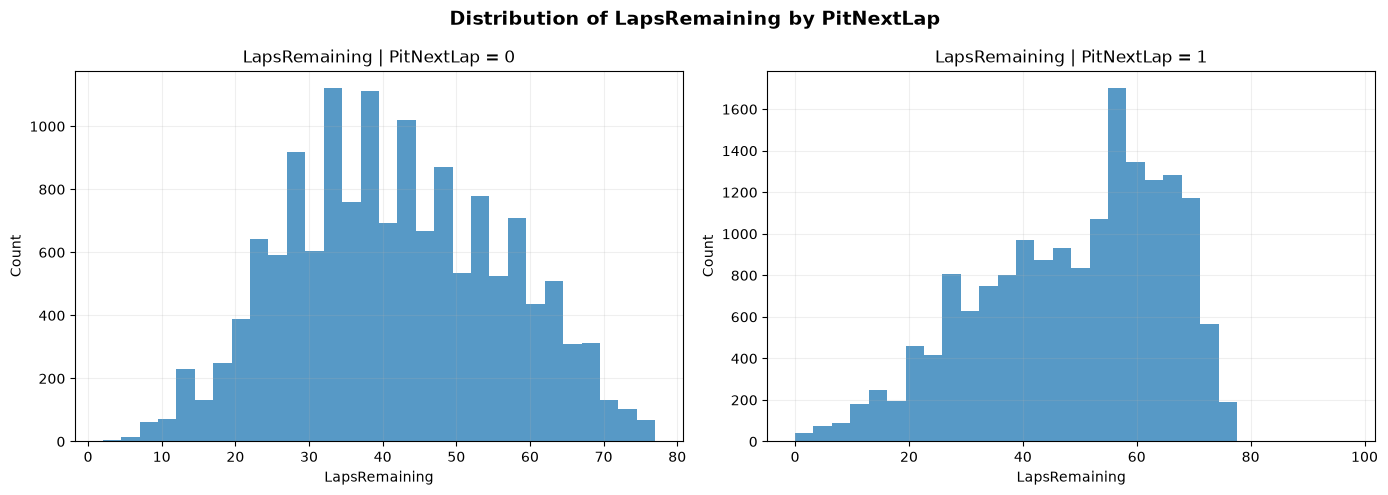

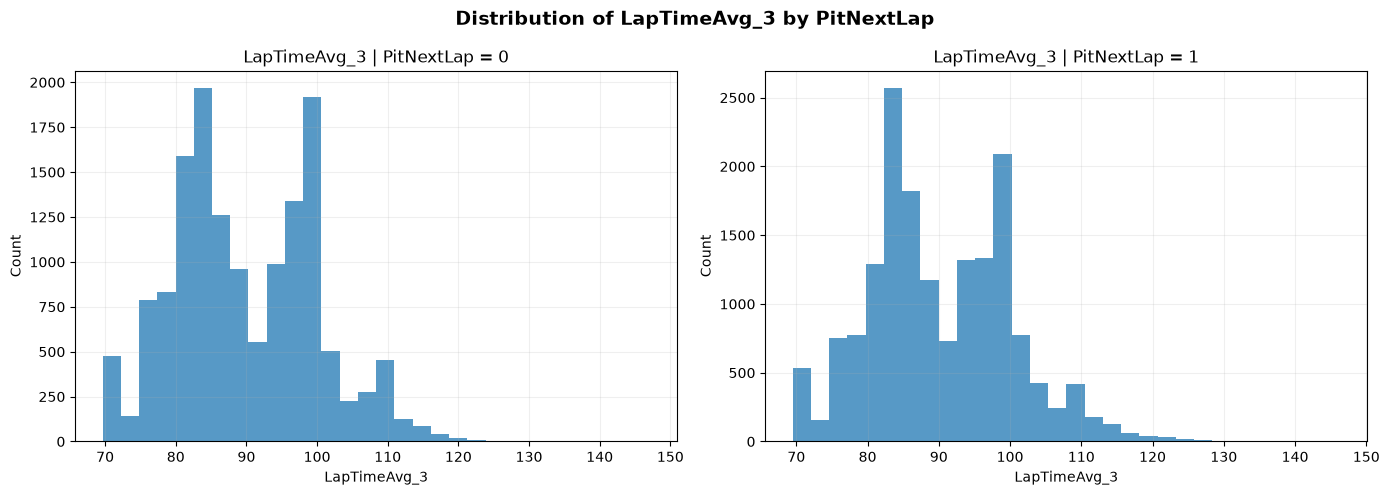

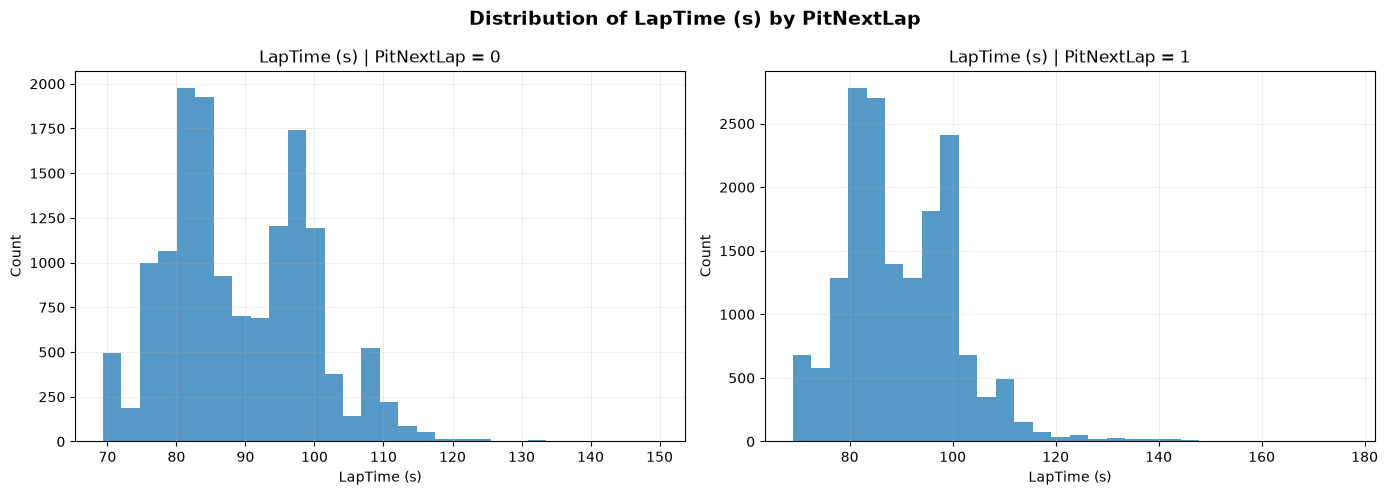

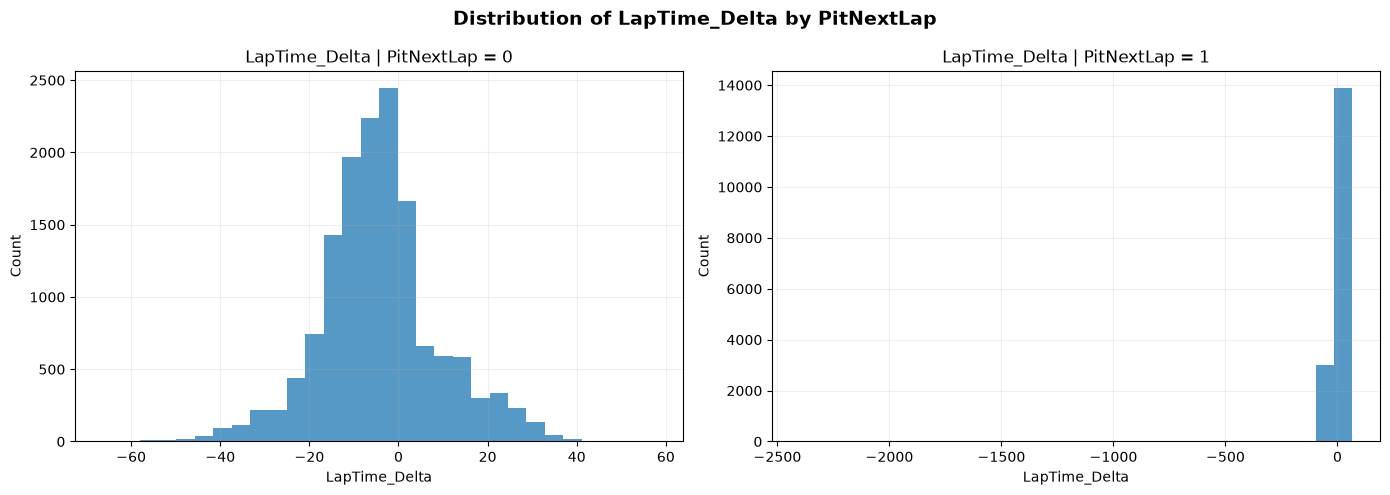

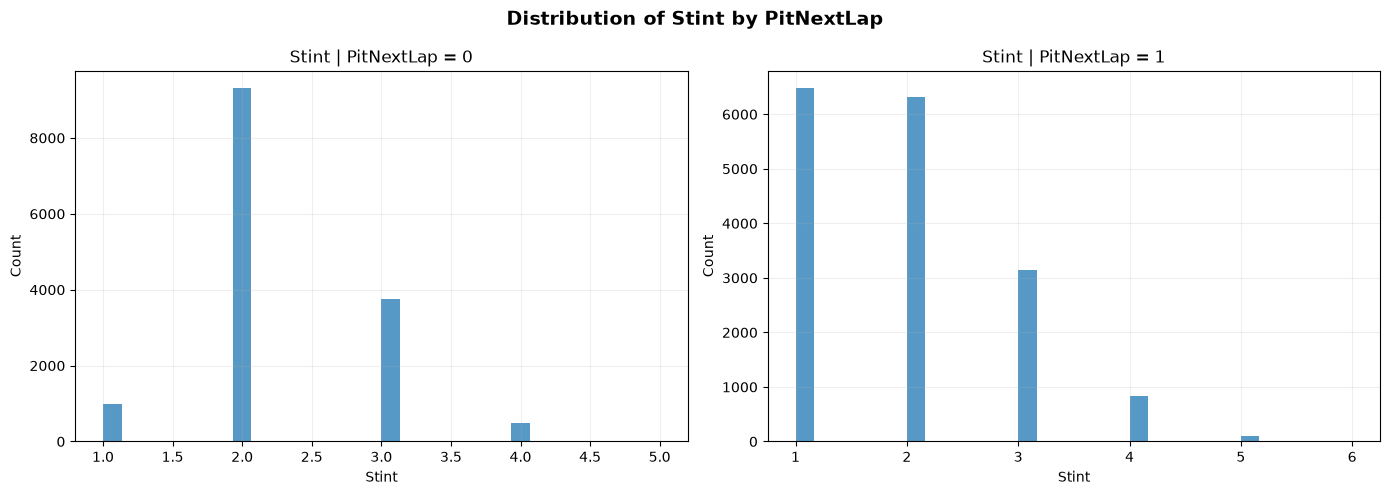

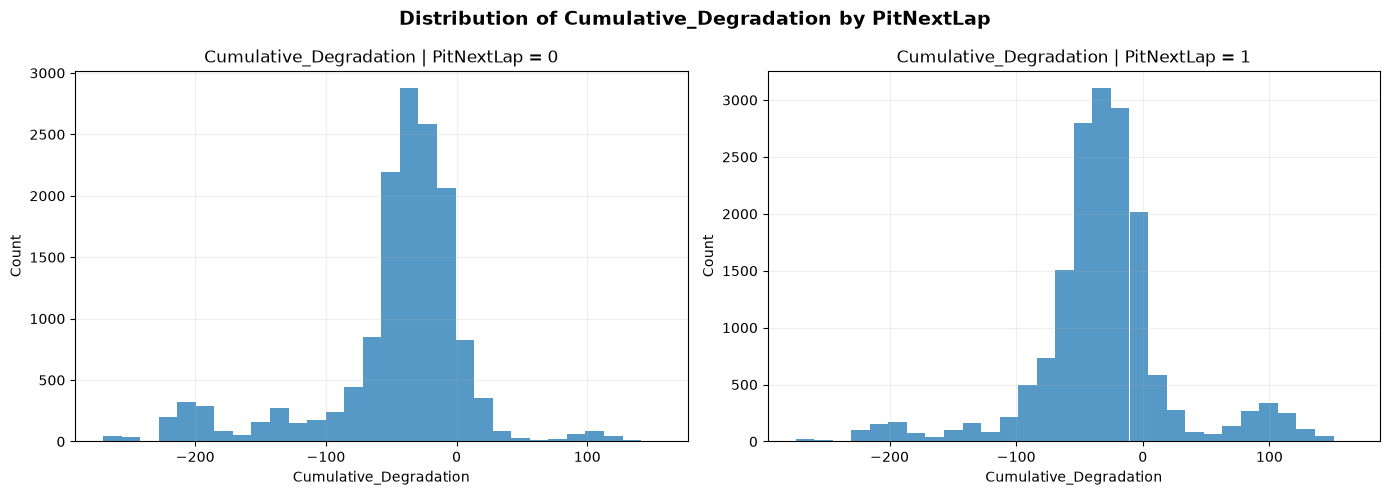

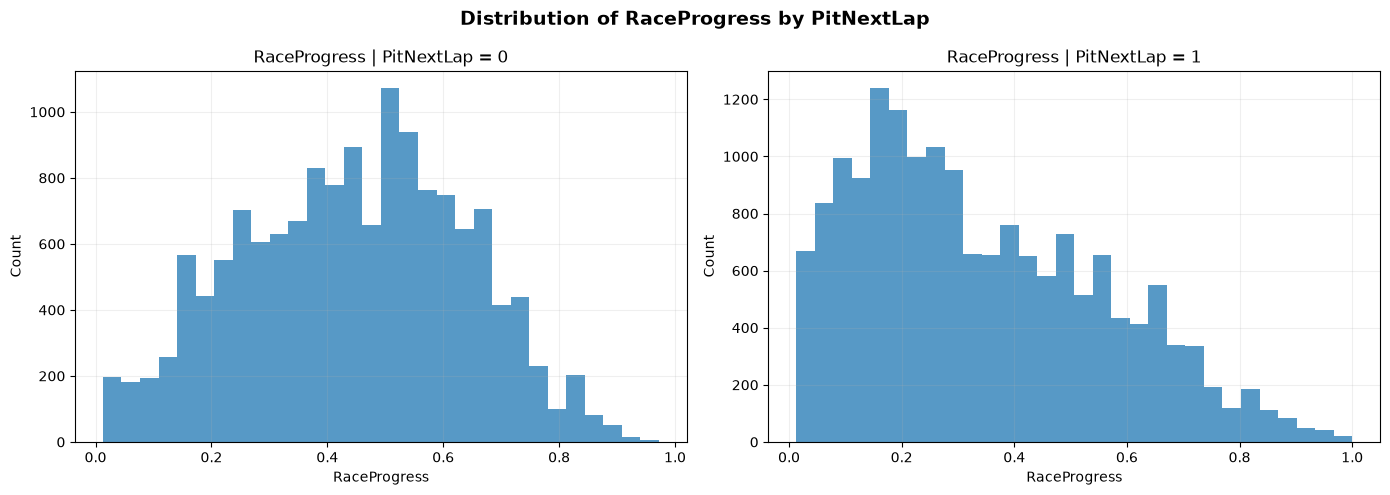

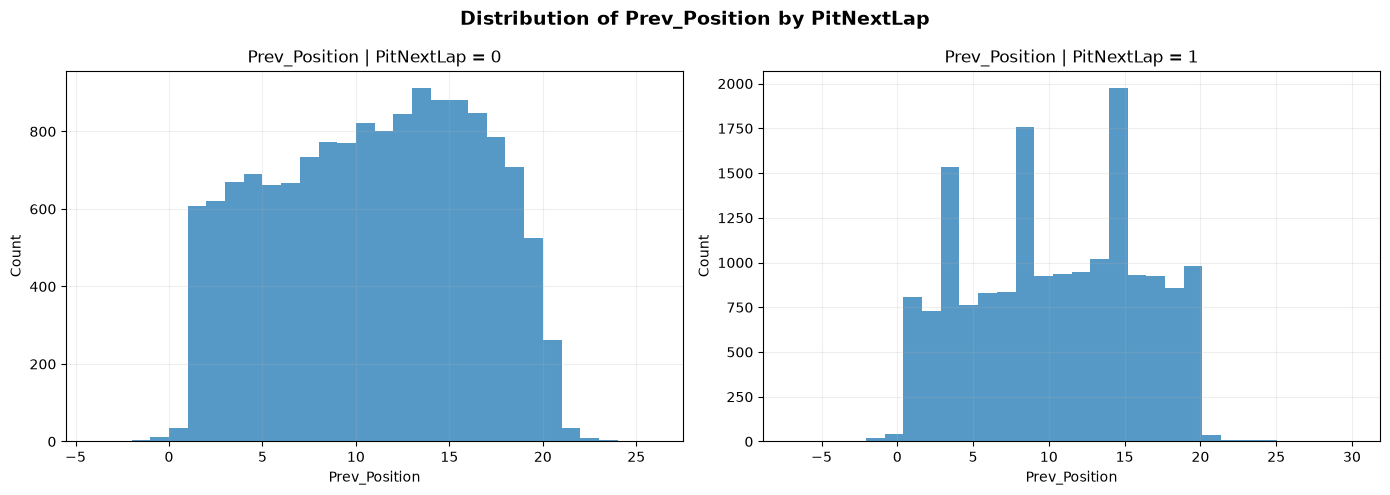

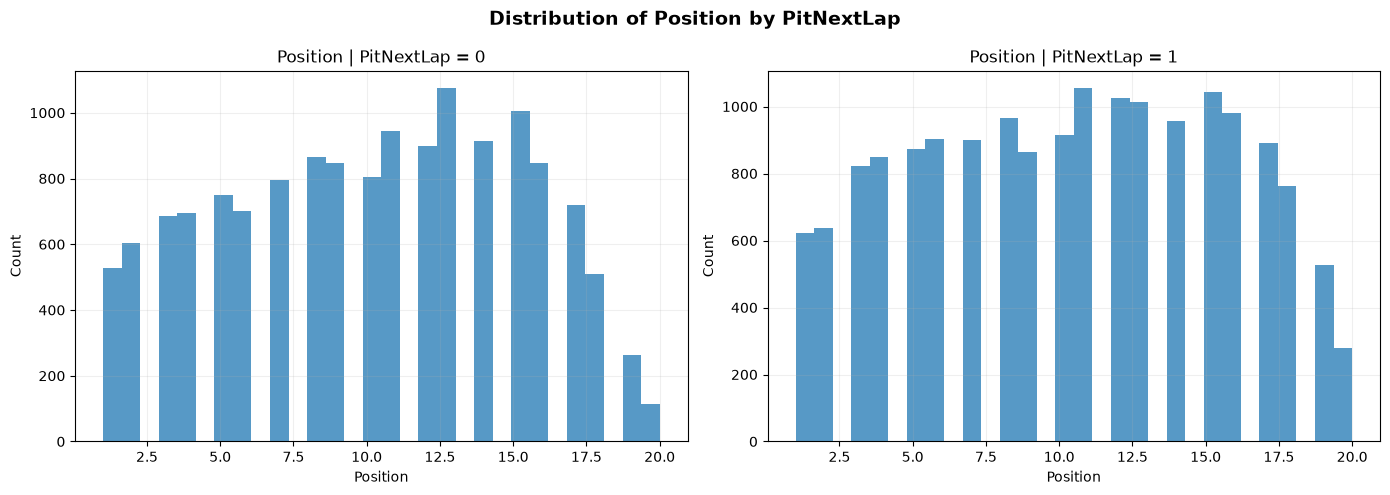

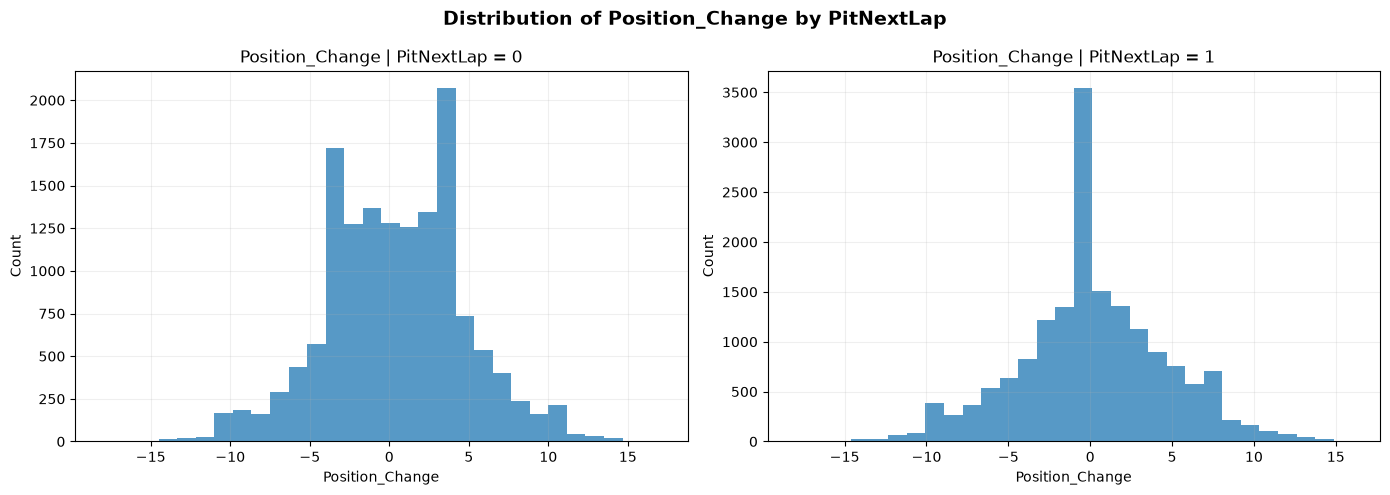

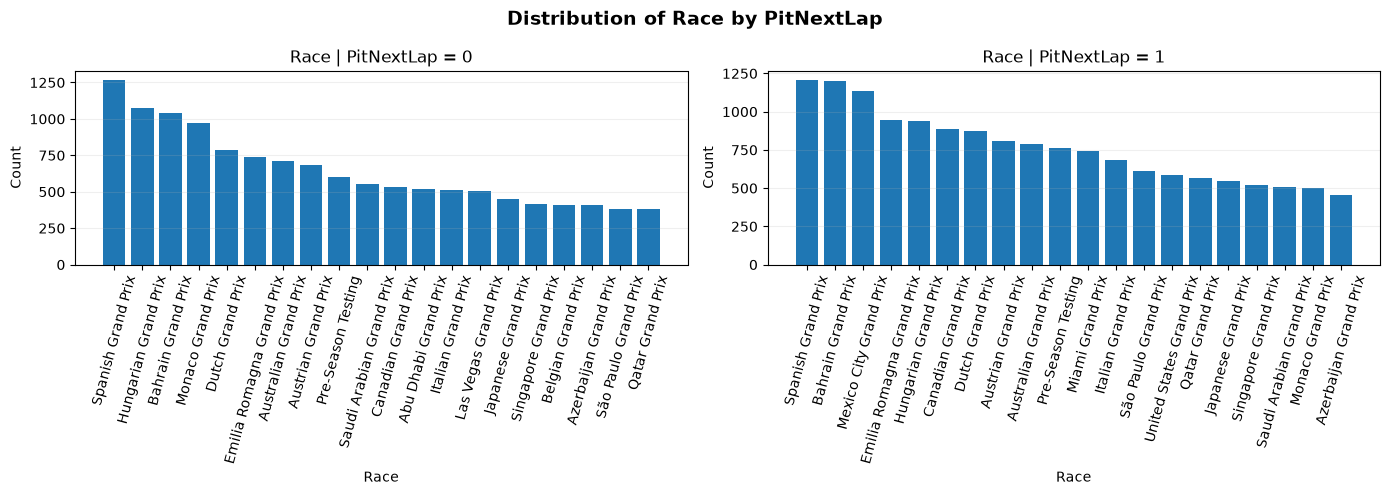

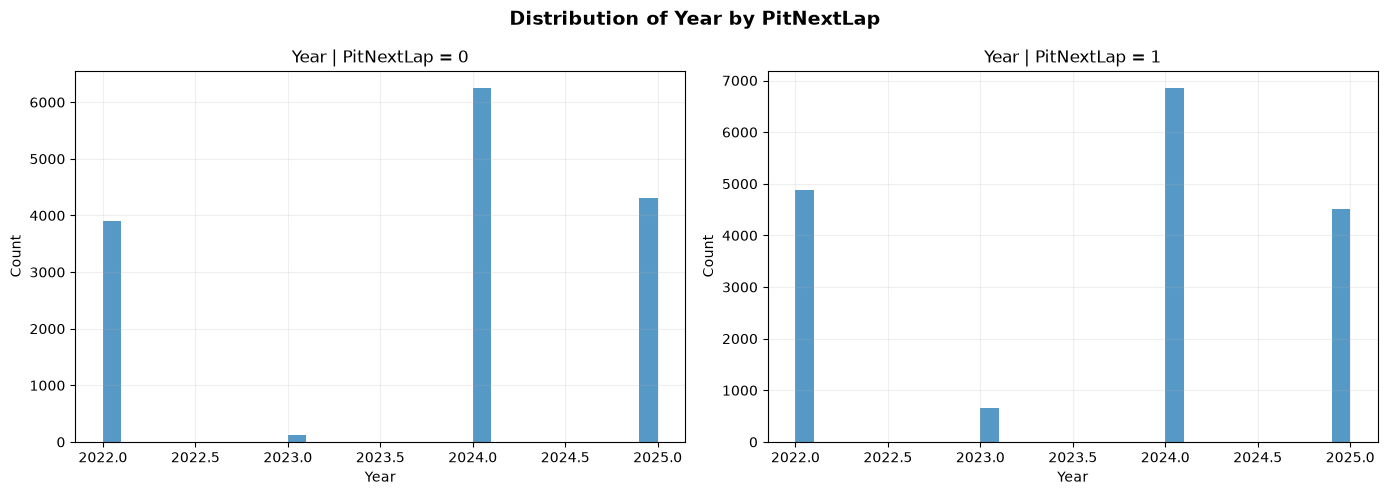

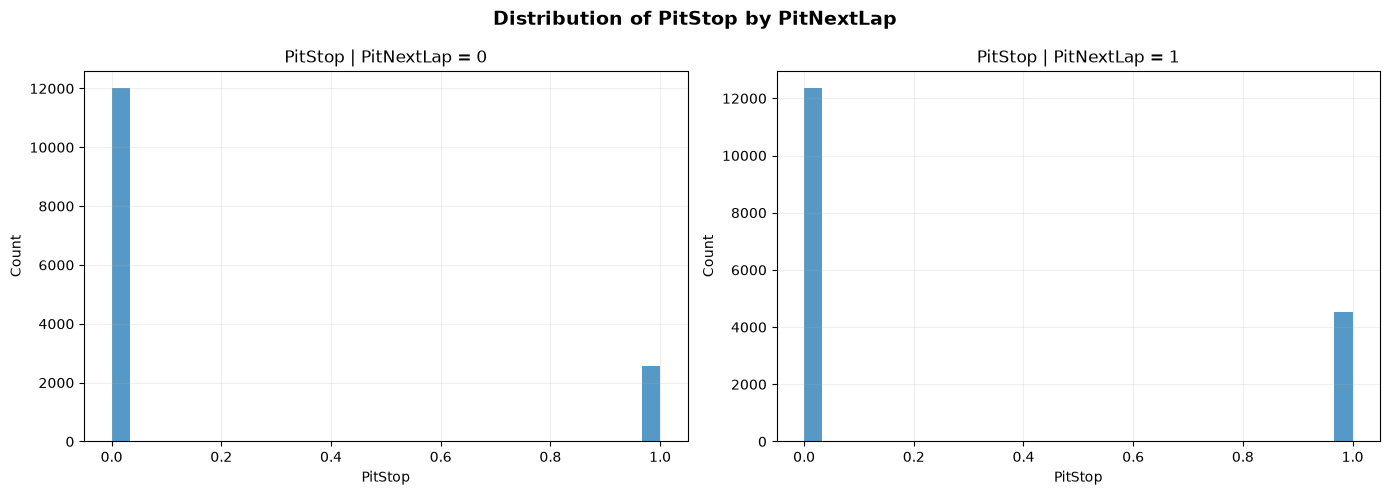

In [14]:
get_graph(mismatched_df)

In [17]:
from get_graph_for_feature_importance import *

               Feature  Cohens_d  Abs_Cohens_d  Variation
              TyreLife -0.748072      0.748072     Medium
             LapNumber -0.523920      0.523920     Medium
            TireAgePct -0.507088      0.507088     Medium
      TireRemainingPct  0.507088      0.507088     Medium
          RaceProgress -0.503845      0.503845     Medium
         LapsRemaining  0.477189      0.477189      Small
           MaxTireLife -0.462198      0.462198      Small
                 Stint -0.422974      0.422974      Small
Cumulative_Degradation  0.250369      0.250369      Small
     TireRemainingLife  0.158492      0.158492 Very Small
              RaceLaps -0.144534      0.144534 Very Small
                  Year -0.088766      0.088766 Very Small
           LapTime (s)  0.063589      0.063589 Very Small
       Position_Change -0.052129      0.052129 Very Small
              Position  0.038537      0.038537 Very Small
         LapTime_Delta -0.038133      0.038133 Very Small
          LapT

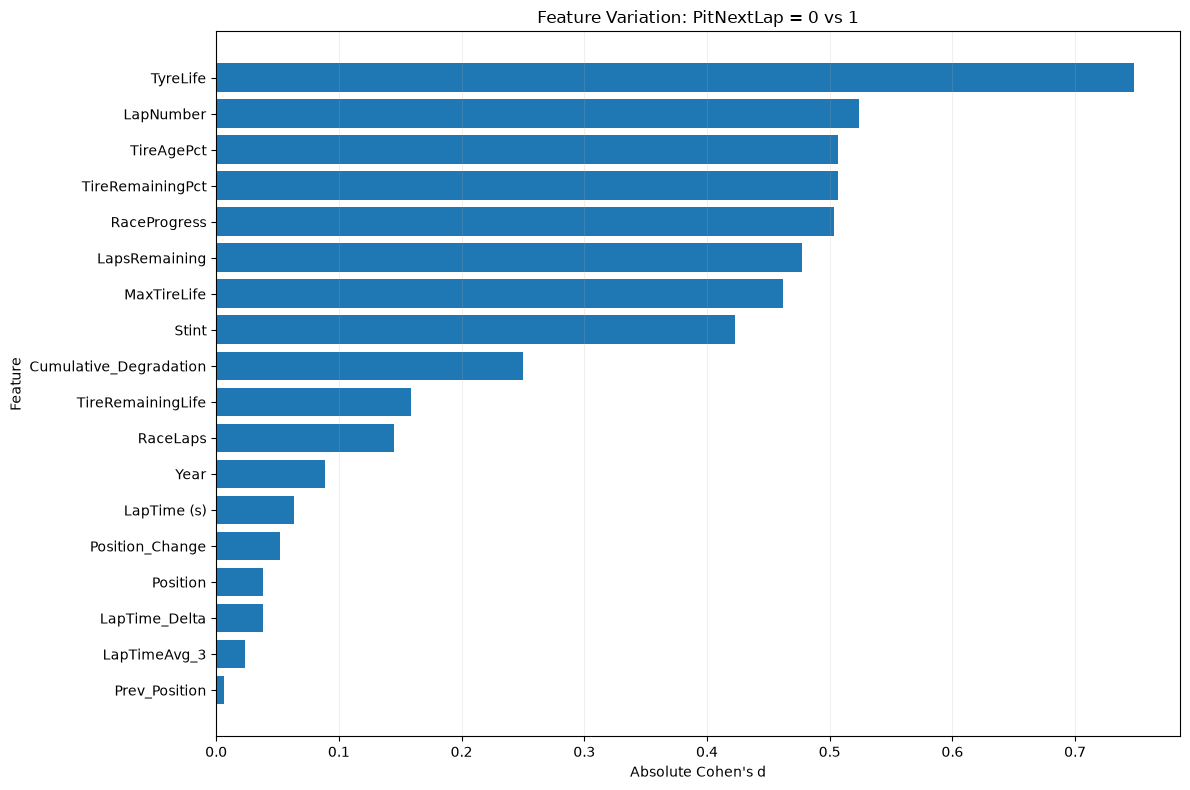

               Feature  Cohens_d  Abs_Cohens_d  Variation
              TyreLife  0.920478      0.920478      Large
             LapNumber  0.838505      0.838505      Large
           MaxTireLife  0.666241      0.666241     Medium
            TireAgePct  0.665877      0.665877     Medium
      TireRemainingPct -0.665877      0.665877     Medium
              RaceLaps  0.642179      0.642179     Medium
                 Stint  0.594212      0.594212     Medium
          RaceProgress  0.580892      0.580892     Medium
Cumulative_Degradation -0.504055      0.504055     Medium
         LapsRemaining -0.383192      0.383192      Small
                  Year  0.364024      0.364024      Small
     TireRemainingLife -0.214930      0.214930      Small
       Position_Change  0.143262      0.143262 Very Small
         Prev_Position  0.137024      0.137024 Very Small
           LapTime (s) -0.091363      0.091363 Very Small
          LapTimeAvg_3 -0.053388      0.053388 Very Small
              

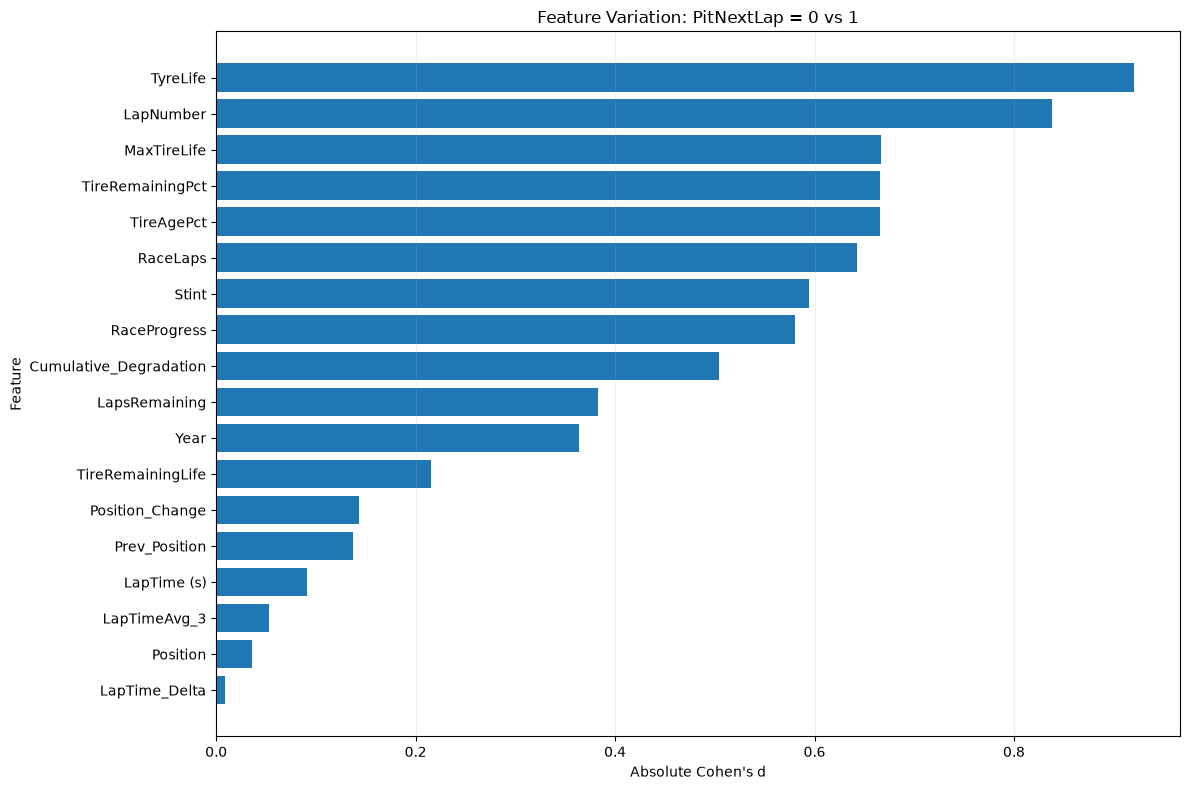

In [23]:
current_sample = "Mismatch"
feature_eng_name ="best_fe"
# get_graph(df_train_merged_fe, columns,current_sample,feature_eng_name)
variation_df1 = analyze_feature_variation(mismatched_df)
plot_variations(variation_df1,current_sample,feature_eng_name)
variation_df2 = analyze_feature_variation(matched_df)
plot_variations(variation_df2,"Match",feature_eng_name)



In [26]:



def compare_numeric_variation(variation_df1, variation_df2):
    
    df1 = variation_df1[
        ['Feature', 'Abs_Cohens_d']
    ].rename(
        columns={'Abs_Cohens_d': 'Score_1'}
    )

    df2 = variation_df2[
        ['Feature', 'Abs_Cohens_d']
    ].rename(
        columns={'Abs_Cohens_d': 'Score_2'}
    )

    comparison = df1.merge(
        df2,
        on='Feature',
        how='outer'
    )

    comparison['Score_1'] = comparison['Score_1'].fillna(0)
    comparison['Score_2'] = comparison['Score_2'].fillna(0)

    comparison['Difference'] = (
        comparison['Score_2'] -
        comparison['Score_1']
    )

    comparison['Abs_Difference'] = (
        comparison['Difference'].abs()
    )

    return comparison.sort_values(
        'Abs_Difference',
        ascending=False
    ).reset_index(drop=True)


variation_comparison = compare_numeric_variation(
    variation_df1,
    variation_df2
)

print(variation_comparison.to_string(index=False))

               Feature  Score_1  Score_2  Difference  Abs_Difference
              RaceLaps 0.144534 0.642179    0.497645        0.497645
             LapNumber 0.523920 0.838505    0.314586        0.314586
                  Year 0.088766 0.364024    0.275257        0.275257
Cumulative_Degradation 0.250369 0.504055    0.253687        0.253687
           MaxTireLife 0.462198 0.666241    0.204043        0.204043
              TyreLife 0.748072 0.920478    0.172406        0.172406
                 Stint 0.422974 0.594212    0.171237        0.171237
      TireRemainingPct 0.507088 0.665877    0.158789        0.158789
            TireAgePct 0.507088 0.665877    0.158789        0.158789
         Prev_Position 0.006468 0.137024    0.130556        0.130556
         LapsRemaining 0.477189 0.383192   -0.093997        0.093997
       Position_Change 0.052129 0.143262    0.091133        0.091133
          RaceProgress 0.503845 0.580892    0.077047        0.077047
     TireRemainingLife 0.158492 0.

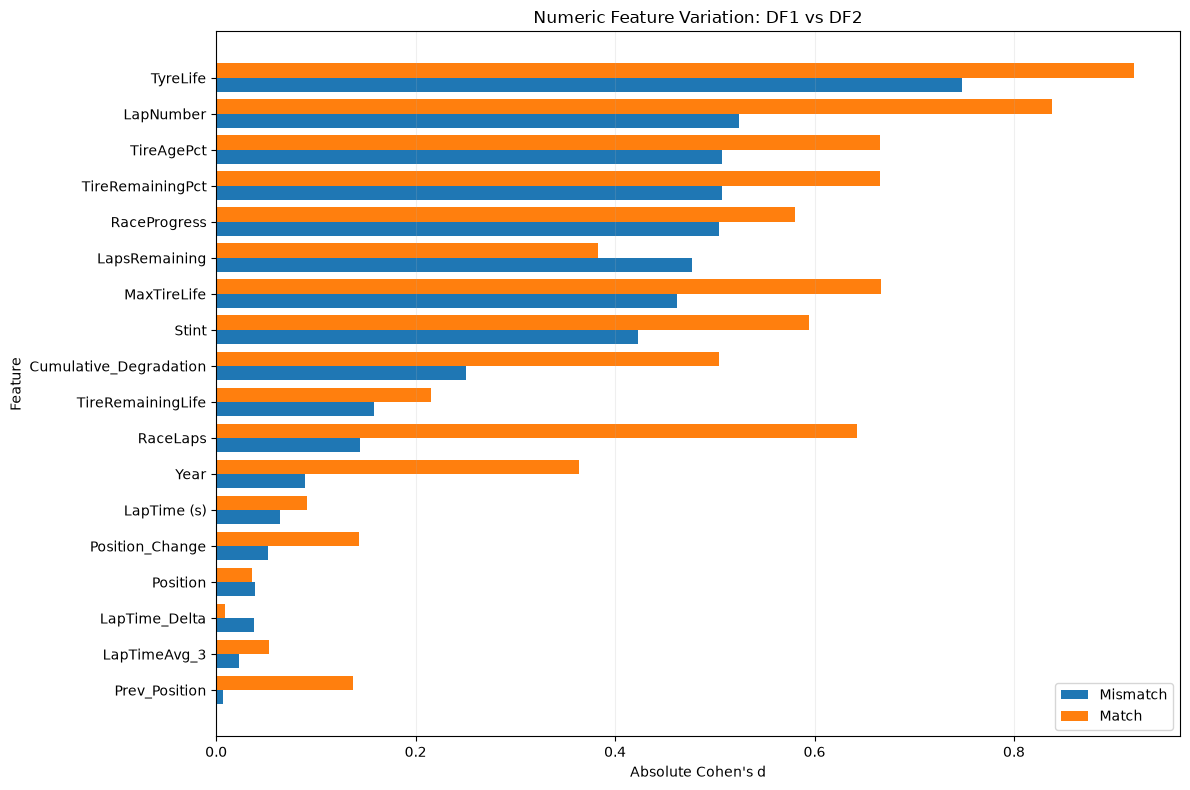

In [28]:
plot_df = (
    variation_comparison
    .sort_values('Abs_Difference', ascending=False)
    .head(20)
    .sort_values('Score_1')
)

plt.figure(figsize=(12, 8))

y = range(len(plot_df))
height = 0.4

plt.barh(
    [i - height/2 for i in y],
    plot_df['Score_1'],
    height=height,
    label='Mismatch'
)

plt.barh(
    [i + height/2 for i in y],
    plot_df['Score_2'],
    height=height,
    label='Match'
)

plt.yticks(
    y,
    plot_df['Feature']
)

plt.xlabel("Absolute Cohen's d")
plt.ylabel("Feature")
plt.title("Numeric Feature Variation: DF1 vs DF2")

plt.legend()
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
mismatched_df["LapsRemaining"].value_counts()

LapsRemaining
38.0    791
34.0    788
58.0    735
56.0    726
43.0    706
       ... 
3.0      18
2.0      10
0.0       9
1.0       5
97.0      1
Name: count, Length: 79, dtype: int64

In [33]:

mismatched_df.count()

id                        31453
Driver                    31453
Compound                  31453
Race                      31453
Year                      31453
PitStop                   31453
LapNumber                 31453
Stint                     31453
TyreLife                  31453
Position                  31453
LapTime (s)               31453
LapTime_Delta             31453
Cumulative_Degradation    31453
RaceProgress              31453
Position_Change           31453
PitNextLap                31453
MaxTireLife               31453
TireRemainingLife         31453
TireAgePct                31453
TireRemainingPct          31453
RaceLaps                  31453
LapsRemaining             31453
Prev_Position             31453
LapTimeAvg_3              31453
actual                    31453
predicted                 31453
confidence                31453
dtype: int64

In [35]:
def add_correct_column(df, actual_col="actual", predicted_col="predicted"):
    df = df.copy()
    df["Correct"] = (
        df[actual_col] == df[predicted_col]
    ).astype(int)
    return df


def confidence_threshold_analysis(
    df,
    confidence_col="confidence",
    actual_col="actual",
    predicted_col="predicted",
    start=0.50,
    end=1.00,
    step=0.05
):
    df = add_correct_column(df, actual_col, predicted_col)

    thresholds = np.arange(start, end + step, step)
    results = []

    for threshold in thresholds:
        selected = df[df[confidence_col] >= threshold]

        if len(selected) == 0:
            continue

        accuracy = selected["Correct"].mean()
        coverage = len(selected) / len(df)

        results.append({
            "Threshold": round(threshold, 2),
            "Accuracy": round(accuracy * 100, 2),
            "Coverage": round(coverage * 100, 2),
            "Samples": len(selected)
        })

    return pd.DataFrame(results)

def find_confidence_threshold(
    df,
    target_accuracy=95,
    min_coverage=50,
    confidence_col="confidence",
    actual_col="actual",
    predicted_col="predicted"
):
    analysis = confidence_threshold_analysis(
        df,
        confidence_col=confidence_col,
        actual_col=actual_col,
        predicted_col=predicted_col
    )

    suitable = analysis[
        (analysis["Accuracy"] >= target_accuracy) &
        (analysis["Coverage"] >= min_coverage)
    ]

    if suitable.empty:
        return None, analysis

    best = suitable.iloc[0]

    return best, analysis

In [36]:
best, analysis = find_confidence_threshold(
    mismatched_df,
    target_accuracy=95,
    min_coverage=50
)

print(analysis.to_string(index=False))
print("\nRecommended threshold:")
print(best)

 Threshold  Accuracy  Coverage  Samples
      0.50       0.0    100.00    31453
      0.55       0.0     81.35    25586
      0.60       0.0     64.73    20361
      0.65       0.0     50.60    15915
      0.70       0.0     38.05    11969
      0.75       0.0     27.66     8701
      0.80       0.0     18.96     5962
      0.85       0.0     11.77     3701
      0.90       0.0      6.27     1973
      0.95       0.0      2.27      715

Recommended threshold:
None
